In [ ]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

!pip install hmmlearn
from hmmlearn.hmm import GaussianHMM

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.0/166.0 kB 15.1 MB/s eta 0:00:00


In [ ]:
tickers = [
    "AAPL",
    "MSFT",
    "TSLA",
    "TSM",
    "PG"
]

start_date = "2018-01-01"
end_date = "2025-01-01"

n_states = 4
n_simulations = 1000
future_days = 252

random_seed = 42

In [ ]:
price_df = yf.download(
    tickers,
    start=start_date,
    end=end_date,
    auto_adjust=True,
    progress=False
)["Close"]

price_df = price_df.dropna()

print("Price Shape:", price_df.shape)
display(price_df.head())

Price Shape: (1761, 5)


Ticker,AAPL,MSFT,PG,TSLA,TSM
Date,,,,,
2018-01-02,40.267071,78.699913,72.280708,21.368668,33.753235
2018-01-03,40.260067,79.066154,72.193008,21.150000,34.320999
2018-01-04,40.447071,79.762062,72.703308,20.974667,34.139973
2018-01-05,40.907578,80.750954,72.751160,21.105333,34.938141
2018-01-08,40.755638,80.833351,73.133896,22.427334,34.921680


In [ ]:
returns_df = np.log(price_df / price_df.shift(1)).dropna()

print("Returns Shape:", returns_df.shape)
display(returns_df.head())

Returns Shape: (1760, 5)


Ticker,AAPL,MSFT,PG,TSLA,TSM
Date,,,,,
2018-01-03,-0.000174,0.004643,-0.001214,-0.010286,0.016681
2018-01-04,0.004634,0.008763,0.007044,-0.008325,-0.005288
2018-01-05,0.011321,0.012322,0.000658,0.006210,0.023110
2018-01-08,-0.003721,0.001020,0.005247,0.060755,-0.000471
2018-01-09,-0.000115,-0.000680,-0.007332,-0.008118,-0.006145


In [ ]:
X = returns_df.values

model = GaussianHMM(
    n_components=n_states,
    covariance_type="full",
    n_iter=1000,
    random_state=random_seed
)

model.fit(X)

print("\nHMM Training Complete")
print("Converged:", model.monitor_.converged)
print("Iterations:", model.monitor_.iter)


HMM Training Complete
Converged: True
Iterations: 47


In [ ]:
hidden_states = model.predict(X)

returns_df["State"] = hidden_states

print("\nState Counts")
print(pd.Series(hidden_states).value_counts().sort_index())



State Counts
0     234
1      86
2    1259
3     181
Name: count, dtype: int64


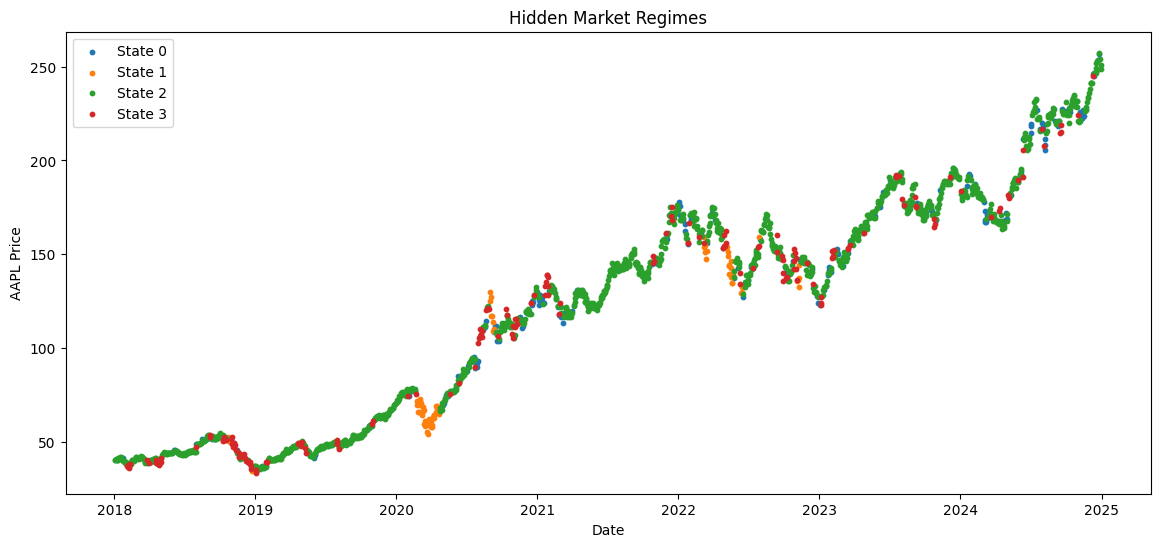

In [ ]:
plt.figure(figsize=(14, 6))

for state in range(n_states):

    mask = hidden_states == state

    plt.scatter(
        returns_df.index[mask],
        price_df.iloc[1:]["AAPL"][mask],
        label=f"State {state}",
        s=10
    )

plt.title("Hidden Market Regimes")
plt.xlabel("Date")
plt.ylabel("AAPL Price")
plt.legend()

plt.show()

In [ ]:
last_prices = price_df.iloc[-1].values

all_simulations = np.zeros(
    (
        n_simulations,
        future_days,
        len(tickers)
    )
)

current_state = hidden_states[-1]

for sim in range(n_simulations):

    state = current_state

    prices = np.zeros((future_days + 1, len(tickers)))

    prices[0] = last_prices

    for t in range(future_days):

        # Transition hidden state
        state = np.random.choice(
            np.arange(n_states),
            p=model.transmat_[state]
        )

        # Sample multivariate return
        simulated_return = np.random.multivariate_normal(
            mean=model.means_[state],
            cov=model.covars_[state]
        )

        prices[t + 1] = prices[t] * np.exp(simulated_return)

    all_simulations[sim] = prices[1:]


print("\nSimulation Tensor Shape:")
print(all_simulations.shape)



Simulation Tensor Shape:
(1000, 252, 5)


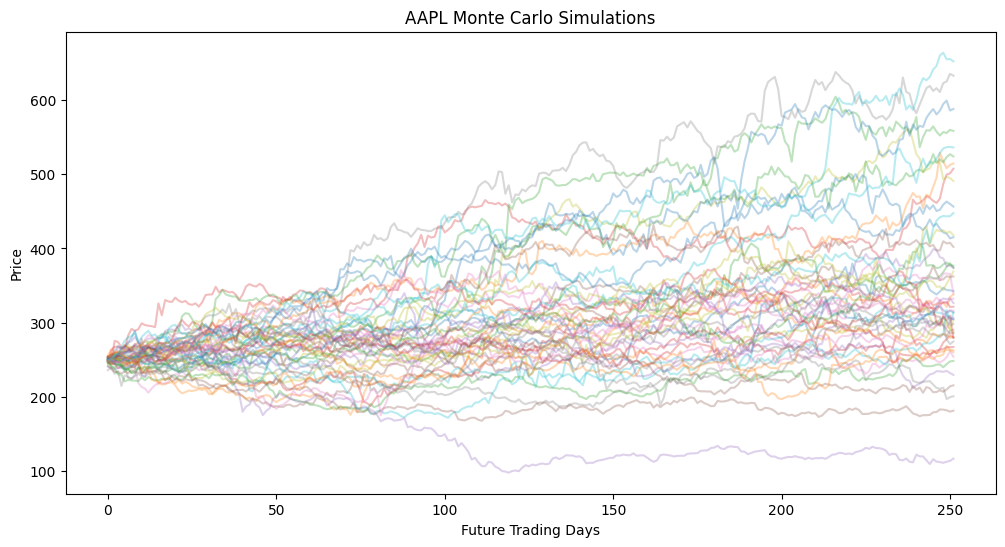

In [ ]:
asset_idx = tickers.index("AAPL")

plt.figure(figsize=(12, 6))

for i in range(50):

    plt.plot(
        all_simulations[i, :, asset_idx],
        alpha=0.3
    )

plt.title("AAPL Monte Carlo Simulations")
plt.xlabel("Future Trading Days")
plt.ylabel("Price")

plt.show()

In [ ]:
beliefs = []

for i, ticker in enumerate(tickers):

    final_prices = all_simulations[:, -1, i]

    start_price = last_prices[i]

    total_returns = (final_prices / start_price) - 1

    expected_return = np.mean(total_returns)

    probability_positive = np.mean(total_returns > 0)

    confidence = abs(probability_positive - 0.5) * 2

    beliefs.append({
        "Ticker": ticker,
        "ExpectedReturn": expected_return,
        "ProbabilityPositive": probability_positive,
        "Confidence": confidence
    })

beliefs_df = pd.DataFrame(beliefs)

print("\nAbsolute Beliefs")
display(beliefs_df)


Absolute Beliefs


,Ticker,ExpectedReturn,ProbabilityPositive,Confidence
0,AAPL,0.368769,0.802,0.604
1,MSFT,0.321734,0.792,0.584
2,TSLA,0.156049,0.725,0.450
3,TSM,0.912850,0.761,0.522
4,PG,0.375624,0.772,0.544


In [ ]:
beliefs = []

for i, ticker in enumerate(tickers):

    final_prices = all_simulations[:, -1, i]

    start_price = last_prices[i]

    total_returns = (final_prices / start_price) - 1

    expected_return = np.mean(total_returns)

    probability_positive = np.mean(total_returns > 0)

    confidence = abs(probability_positive - 0.5) * 2

    beliefs.append({
        "Ticker": ticker,
        "ExpectedReturn": expected_return,
        "ProbabilityPositive": probability_positive,
        "Confidence": confidence
    })

beliefs_df = pd.DataFrame(beliefs)

print("\nBeliefs")
display(beliefs_df)


Beliefs


,Ticker,ExpectedReturn,ProbabilityPositive,Confidence
0,AAPL,0.368769,0.802,0.604
1,MSFT,0.321734,0.792,0.584
2,TSLA,0.156049,0.725,0.450
3,TSM,0.912850,0.761,0.522
4,PG,0.375624,0.772,0.544


In [ ]:
from itertools import combinations

relative_beliefs = []

# Final simulated prices:
# shape = (n_simulations, n_assets)
final_prices = all_simulations[:, -1, :]

# Starting prices
start_prices = last_prices

# Convert to total returns
# shape = (n_simulations, n_assets)
simulated_returns = (
    final_prices / start_prices
) - 1


# ============================================================
# LOOP THROUGH ALL ASSET PAIRS
# ============================================================

for asset_a_idx, asset_b_idx in combinations(range(len(tickers)), 2):

    asset_a = tickers[asset_a_idx]
    asset_b = tickers[asset_b_idx]

    # Relative return in EACH simulation
    #
    # Example:
    #   AAPL_return - MSFT_return
    #
    relative_diff = (
        simulated_returns[:, asset_a_idx]
        - simulated_returns[:, asset_b_idx]
    )

    mean_diff = np.mean(relative_diff)

    std_diff = np.std(relative_diff)

    prob_outperform = np.mean(relative_diff > 0)

    relative_beliefs.append({
        "Asset_A": asset_a,
        "Asset_B": asset_b,
        "MeanRelativeReturn": mean_diff,
        "StdRelativeReturn": std_diff,
        "ProbabilityOutperform": prob_outperform
    })


# ============================================================
# RESULTS DATAFRAME
# ============================================================

relative_beliefs_df = pd.DataFrame(relative_beliefs)

print("\nRelative Beliefs")
display(relative_beliefs_df)


# ============================================================
# OPTIONAL:
# SORT STRONGEST RELATIVE VIEWS
# ============================================================

sorted_relative_beliefs = relative_beliefs_df.sort_values(
    by="MeanRelativeReturn",
    ascending=False
)

print("\nStrongest Relative Views")
display(sorted_relative_beliefs)



Relative Beliefs


,Asset_A,Asset_B,MeanRelativeReturn,StdRelativeReturn,ProbabilityOutperform
0,AAPL,MSFT,0.047035,0.314825,0.530
1,AAPL,TSLA,0.212720,0.411514,0.681
2,AAPL,TSM,-0.544081,1.200255,0.375
3,AAPL,PG,-0.006855,0.456424,0.526
4,MSFT,TSLA,0.165685,0.363083,0.651
5,MSFT,TSM,-0.591116,1.220627,0.365
6,MSFT,PG,-0.053890,0.433060,0.470
7,TSLA,TSM,-0.756801,1.318307,0.306
8,TSLA,PG,-0.219575,0.498022,0.341
9,TSM,PG,0.537226,1.215312,0.641



Strongest Relative Views


,Asset_A,Asset_B,MeanRelativeReturn,StdRelativeReturn,ProbabilityOutperform
9,TSM,PG,0.537226,1.215312,0.641
1,AAPL,TSLA,0.212720,0.411514,0.681
4,MSFT,TSLA,0.165685,0.363083,0.651
0,AAPL,MSFT,0.047035,0.314825,0.530
3,AAPL,PG,-0.006855,0.456424,0.526
6,MSFT,PG,-0.053890,0.433060,0.470
8,TSLA,PG,-0.219575,0.498022,0.341
2,AAPL,TSM,-0.544081,1.200255,0.375
5,MSFT,TSM,-0.591116,1.220627,0.365
7,TSLA,TSM,-0.756801,1.318307,0.306


In [ ]:
beliefs_df.to_csv("hmm_absolute_beliefs.csv", index=False)
relative_beliefs_df.to_csv("hmm_relative_beliefs.csv", index=False)

print("Absolute beliefs exported to absolute_beliefs.csv")
print("Relative beliefs exported to relative_beliefs.csv")

Absolute beliefs exported to absolute_beliefs.csv
Relative beliefs exported to relative_beliefs.csv
